In [1]:
import h5py
import numpy as np
from scipy.special import stdtrit
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from libra_py import units
import warnings
warnings.filterwarnings("ignore")
import scipy.sparse as sp
from matplotlib.colors import ListedColormap
from scipy.constants import physical_constants
from libra_py import trpes
import os

In [8]:
def fit_namd_data(methods, iconds, fitting_for_method, figuretitle, figurename="figure.png", conf_level = 0.95, r2_min = 0.7):

    # Create a 1x1 grid of subplots with a more square-like figure size
    fig, ax = plt.subplots(1, 1, figsize=(8, 6), sharex=True)

    # Loop through each method
    for c, method in enumerate(['FSSH2']):
        taus = []
        fit_function = fitting_for_method[method]
    
        for icond in iconds:
            try:
                with h5py.File(f'{method}0_icond_{icond}/mem_data.hdf', 'r') as F:
                    sh_pop = np.array(F['sh_pop_adi/data'][:, 0])
                    md_time = np.array(F['time/data'][:]) * units.au2fs
            except FileNotFoundError:
                print(f"File not found: {method}_icond_{icond}/mem_data.hdf, skipping.")
                continue

            popt, pcov = curve_fit(fit_function, md_time, sh_pop, bounds=([0.0], [np.inf]))
            tau = popt
            residuals = sh_pop - fit_function(md_time, *popt)
            ss_res = np.sum(residuals**2)
            ss_tot = np.sum((sh_pop - np.mean(sh_pop))**2)
            r_squared = 1.0 - (ss_res / ss_tot)

            print(f"icond: {icond}, r_squared: {r_squared}, tau: {tau}")  # Print r_squared for each icond

            # Only append tau and plot if r_squared is greater than 0.1        
            if r_squared > r2_min:
                ax.plot(md_time, sh_pop, color='blue', linewidth=2.0)  # Line color is black
                taus.append(tau)
                print(F"plotting this batch, the fitted tau is {tau}")
            else:
                ax.plot(md_time, sh_pop, color='grey', linewidth=2.0) 

        taus = np.array(taus)
        if len(taus) > 0:  # Proceed only if there are valid taus
            ave_tau = np.average(taus)
            s = np.std(taus)            
            N = taus.shape[0]
            #Z = 1.96 - naive value
            Z = stdtrit(N-1, conf_level) # better approach
            print(F"Z = {Z}")
            error_bar = Z * s / np.sqrt(N) 
        
            # Convert timescale to picoseconds (ps)
            ave_tau_ps = ave_tau / 1000
            error_bar_ps = error_bar / 1000
        
            print(f'The timescales for method {method}: \n {ave_tau_ps}+-{error_bar_ps} ps, averaged over {len(taus)} samples')

            ax.plot(md_time, fit_function(md_time, ave_tau - error_bar), ls='--', color="red", linewidth=2.0)
        
            # Increase the linewidth of the solid red line
            ax.plot(md_time, fit_function(md_time, ave_tau), ls='-', color="red", label=f"{method}: {ave_tau_ps:.1f} ± {error_bar_ps:.1f} ps \n \
$R^2$: {r2_min} confidence: {conf_level*100}%", linewidth=4)
        
            ax.plot(md_time, fit_function(md_time, ave_tau + error_bar), ls='--', color="red", linewidth=2.0)
            ax.fill_between(md_time, fit_function(md_time, ave_tau - error_bar), fit_function(md_time, ave_tau + error_bar), color='red', alpha=0.1, linewidth=2.0)

        # Set the same plot settings as before
        ax.tick_params(axis='x', labelsize=24, width=2.5, length=10)
        ax.tick_params(axis='y', labelsize=24, width=2.5, length=10)
        ax.set_xlim(left=-500, right=4001)
        ax.set_ylim(bottom=-0.001, top=0.021)
        ax.set_facecolor('white')

        for spine in ax.spines.values():
            spine.set_linewidth(2.5)

        ax.set_title(F'{figuretitle}', fontsize=26, pad=20, x=0.45)
        ax.set_xlabel('Time, fs', fontsize=26)
        ax.set_ylabel('Population', fontsize=26)

        ax.legend(fontsize=20, loc='upper left')
        fig.patch.set_facecolor('white')
        ax.set_xticks(np.arange(0, 3001, 1000))
        ax.set_ylim(0, 0.09)
        ax.set_xlim(0, 3000)
        yticks = np.linspace(0, 0.09, 5)
        #yticklabels = [f"{y:.5f}" for y in yticks]
        
        yticklabels = [f"{y:.3f}" for y in yticks]


        ax.set_yticks(yticks)
        ax.set_yticklabels(yticklabels, fontsize=24)
        plt.tight_layout()
        plt.savefig(F'{figurename}', dpi=600)
        plt.show()

In [9]:
# Fitting functions

def exp_func(x, a):
    return 1 - np.exp(-x / a)

def gau_func(x, a):
    return 1 - np.exp(-x**2 / a**2)

icond: 1, r_squared: 0.9552194289592945, tau: [8692.44157299]
plotting this batch, the fitted tau is [8692.44157299]
icond: 101, r_squared: 0.9767420340146055, tau: [12722.60049253]
plotting this batch, the fitted tau is [12722.60049253]
icond: 201, r_squared: 0.978457069413137, tau: [10402.49548963]
plotting this batch, the fitted tau is [10402.49548963]
icond: 301, r_squared: 0.9648308029695246, tau: [9878.16840092]
plotting this batch, the fitted tau is [9878.16840092]
icond: 401, r_squared: 0.9572972999745832, tau: [9237.72660559]
plotting this batch, the fitted tau is [9237.72660559]
icond: 501, r_squared: 0.9089063337087225, tau: [12831.94607881]
plotting this batch, the fitted tau is [12831.94607881]
icond: 601, r_squared: 0.8965325440611258, tau: [9151.05284709]
plotting this batch, the fitted tau is [9151.05284709]
icond: 701, r_squared: 0.8467632598533233, tau: [9503.73170442]
plotting this batch, the fitted tau is [9503.73170442]
icond: 801, r_squared: 0.9003288382126542, ta

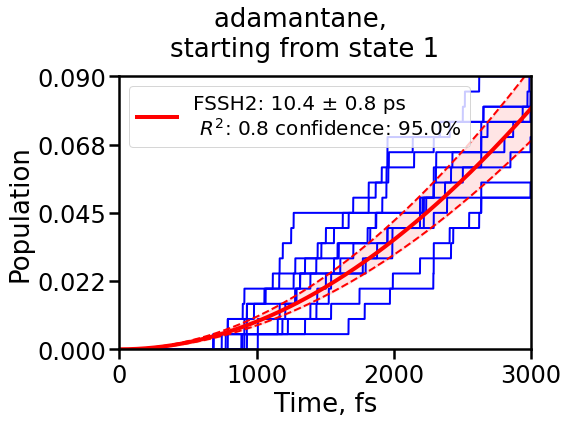

In [10]:
methods = ["FSSH2"]
iconds = list(range(1, 1000, 100))
fitting_for_method = {'FSSH2': gau_func } 
figuretitle = "adamantane, \nstarting from state 1"
figurename = "FSSH2-gau.png"

fit_namd_data(methods, iconds, fitting_for_method, figuretitle, figurename, conf_level = 0.95, r2_min = 0.8)

In addition to the data presented in the main article and the Supporting Information, additional data visualizations are provided below. The visualization procedures were adapted from the the [Libra TRPES plotting tutorial](https://github.com/compchem-cybertraining/Tutorials_Libra/blob/master/6_dynamics/2_nbra_workflows/18_plotting_trpes/tutorial.ipynb).

In [3]:
iconds = list(range(1, 1000, 100))  # ICONDS: 1,101,201,...
method = "FSSH2"
color = "black"

au2ev = physical_constants["hartree-electron volt relationship"][0]
au2fs = physical_constants["atomic unit of time"][0] * 1e15

FIGSIZE = (16, 12)   
font_size = 40
tick_font = 32

# ========== TRPES 计算 ==========
x = {
    "istep": 5900,
    "fstep": 8900,
    "dt": 1.0,
    "namd_nsteps": 3000,
    "units": "eV",
    "eprefix": "/vscratch/grp-alexeyak/qingxin/devel3_300K_11_23/step2_B3LYP/all_logfiles/step_",
    "esuffix": ".log",
    "input_file_type": 1,
    "logfile_read_params": {"number_of_states": 30},
    "iconds": iconds,
    "dprefix": "/vscratch/grp-alexeyak/qingxin/devel3_300K_11_23/step4/S1_FSSH2_test/FSSH20_icond_",
    "dsuffix": "/mem_data.hdf",
    "de": 0.1,
    "emin": 0.0,
    "emax": 10.0,
    "sigma_e": 0.6,
}

time_bins, energy_grid, H_total = trpes.compute_trpes(x)


def refined_func(t, tau, E0, E1):
    return (E0 - E1) * np.exp(-(t / tau) ** 2) + E1


energies = []
Hvib_path = "/vscratch/grp-alexeyak/qingxin/devel3_300K_11_23/step33three_B3LYP"
for step in range(5900, 8900):
    hv_file = f"{Hvib_path}/Hvib_ci_{step}_re.npz"
    hvib = sp.load_npz(hv_file).todense().real
    energies.append(np.diag(hvib))

energies = np.array(energies)   # (nsteps, nstates)
energies = au2ev * energies
adiabatic_energies = energies
e2 = energies


all_excess_energies = []
taus = []
time_ref = None

for icond in iconds:
    h5_path = f"/vscratch/grp-alexeyak/qingxin/devel3_300K_11_23/step4/S1_FSSH2_test/{method}0_icond_{icond}/mem_data.hdf"
    try:
        with h5py.File(h5_path, "r") as F:
            sh_pop = np.array(F["sh_pop_adi/data"])          # (nsteps, nstates)
            time = np.array(F["time/data"])[0:3000] * au2fs  # fs

        if time_ref is None:
            time_ref = time

        tmp2 = np.roll(e2[0:3000, :], -icond, axis=0)
        tmp1 = sh_pop[0:3000, :] * tmp2
        tmp = np.sum(tmp1, axis=1)

        all_excess_energies.append(tmp)

        E0 = tmp[0]
        E1 = adiabatic_energies[:, 1].mean()

        popt, _ = curve_fit(
            lambda t, tau: refined_func(t, tau, E0, E1),
            time,
            tmp,
            maxfev=10000,
        )
        taus.append(popt[0])

    except Exception as e:
        print(f"[WARN] icond {icond} 出错: {e}")

if len(all_excess_energies) == 0:
    raise RuntimeError("something wrong.")

avg_excess_energy = np.mean(all_excess_energies, axis=0)


base_cmap = plt.cm.get_cmap("coolwarm")
colors = base_cmap(np.linspace(0.0, 1.0, 256))
cmap_no_blue_purple = ListedColormap(colors)


energy_levels = []
for step in range(5900, 8900):
    file_path = f"{Hvib_path}/Hvib_ci_{step}_re.npz"
    if os.path.exists(file_path):
        Hvib = sp.load_npz(file_path).todense().real
        diag_energies = np.diag(Hvib) * au2ev
        energy_levels.extend(diag_energies)

energy_levels = np.array(energy_levels)

uvvis_path = "ad.txt"
x_spec, y_spec = [], []
with open(uvvis_path, "r") as f:
    for line in f:
        if line.strip():
            parts = line.split()
            x_spec.append(float(parts[0]))
            y_spec.append(float(parts[1]))

x_spec = np.array(x_spec)
y_spec = np.array(y_spec)

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=FIGSIZE,
    sharey=True,
    gridspec_kw={"wspace": 0.15}
)

# ---------- left：TRPES ----------
extent = [time_bins[0], time_bins[-1], energy_grid[0], energy_grid[-1]]

im = ax1.imshow(
    H_total.T,
    extent=extent,
    origin="lower",
    aspect="auto",
    cmap=cmap_no_blue_purple,
)

ax1.plot(
    time_ref[:len(avg_excess_energy)],
    avg_excess_energy,
    color=color,
    linewidth=3,
)

ax1.set_xlim(0, 3000)
ax1.set_xticks(np.arange(0, 3001, 1000))

ax1.set_ylim(0, 10)
ax1.set_ylabel("Energy (eV)", fontsize=font_size)

ax1.tick_params(axis="x", labelsize=tick_font, pad=15)
ax1.tick_params(axis="y", labelsize=tick_font, pad=15)


cbar = fig.colorbar(im, ax=ax1, pad=0.02)
cbar.set_label("Population", fontsize=font_size, labelpad=15)
cbar.ax.tick_params(labelsize=tick_font)

# ---------- right：DOS + UV-VIS ----------
hist_values, bins, _ = ax2.hist(
    energy_levels,
    bins=50,
    density=True,
    orientation="horizontal",
    color="gray",
    edgecolor="black",
    alpha=0.7,
)

max_hist_value = hist_values.max()
scaling_factor = max_hist_value / max(y_spec)
y_norm = y_spec * scaling_factor

ax2.plot(
    y_norm,
    x_spec,
    linestyle="-",
    color="red",
    linewidth=3,
    label="UV-VIS",
)

ax2.set_ylim(0, 10)
ax2.tick_params(axis="y", which="both", left=False, labelleft=False)
ax2.tick_params(axis="x", labelsize=tick_font, pad=15)
ax2.legend(fontsize=28, loc="upper right")


fig.subplots_adjust(left=0.10, right=0.95, bottom=0.12, top=0.96)


pos = ax2.get_position()

shift = 0.03          
width_factor = 0.97    
new_x0 = pos.x0 + shift
new_width = pos.width * width_factor
ax2.set_position([new_x0, pos.y0, new_width, pos.height])

fig.savefig("TRPES_DOS_UVVIS_adamantane.png", dpi=300)
plt.show()

{'istep': 5900, 'fstep': 8900, 'dt': 1.0, 'namd_nsteps': 3000, 'units': 'eV', 'eprefix': '/vscratch/grp-alexeyak/qingxin/devel3_300K_11_23/step2_B3LYP/all_logfiles/step_', 'esuffix': '.log', 'input_file_type': 1, 'logfile_read_params': {'number_of_states': 30}, 'iconds': [1, 101, 201, 301, 401, 501, 601, 701, 801, 901], 'dprefix': '/vscratch/grp-alexeyak/qingxin/devel3_300K_11_23/step4/S1_FSSH2_test/FSSH20_icond_', 'dsuffix': '/mem_data.hdf', 'de': 0.1, 'emin': 0.0, 'emax': 10.0, 'sigma_e': 0.6}
Trajectory data contains 3002, while we only want 3000
The TRPES plot will be of the time legnth of 3000 points
The multiplication factor is 1
The shape of the effective E array is (3000, 31)
Initial iconds = [1, 101, 201, 301, 401, 501, 601, 701, 801, 901]
Renormalizing iconds for istep = 5900, fstep = 8900 and nsteps = 3000...
The effective iconds are = [1, 101, 201, 301, 401, 501, 601, 701, 801, 901] (dropping off meaningless iconds)
Reading the file /vscratch/grp-alexeyak/qingxin/devel3_300

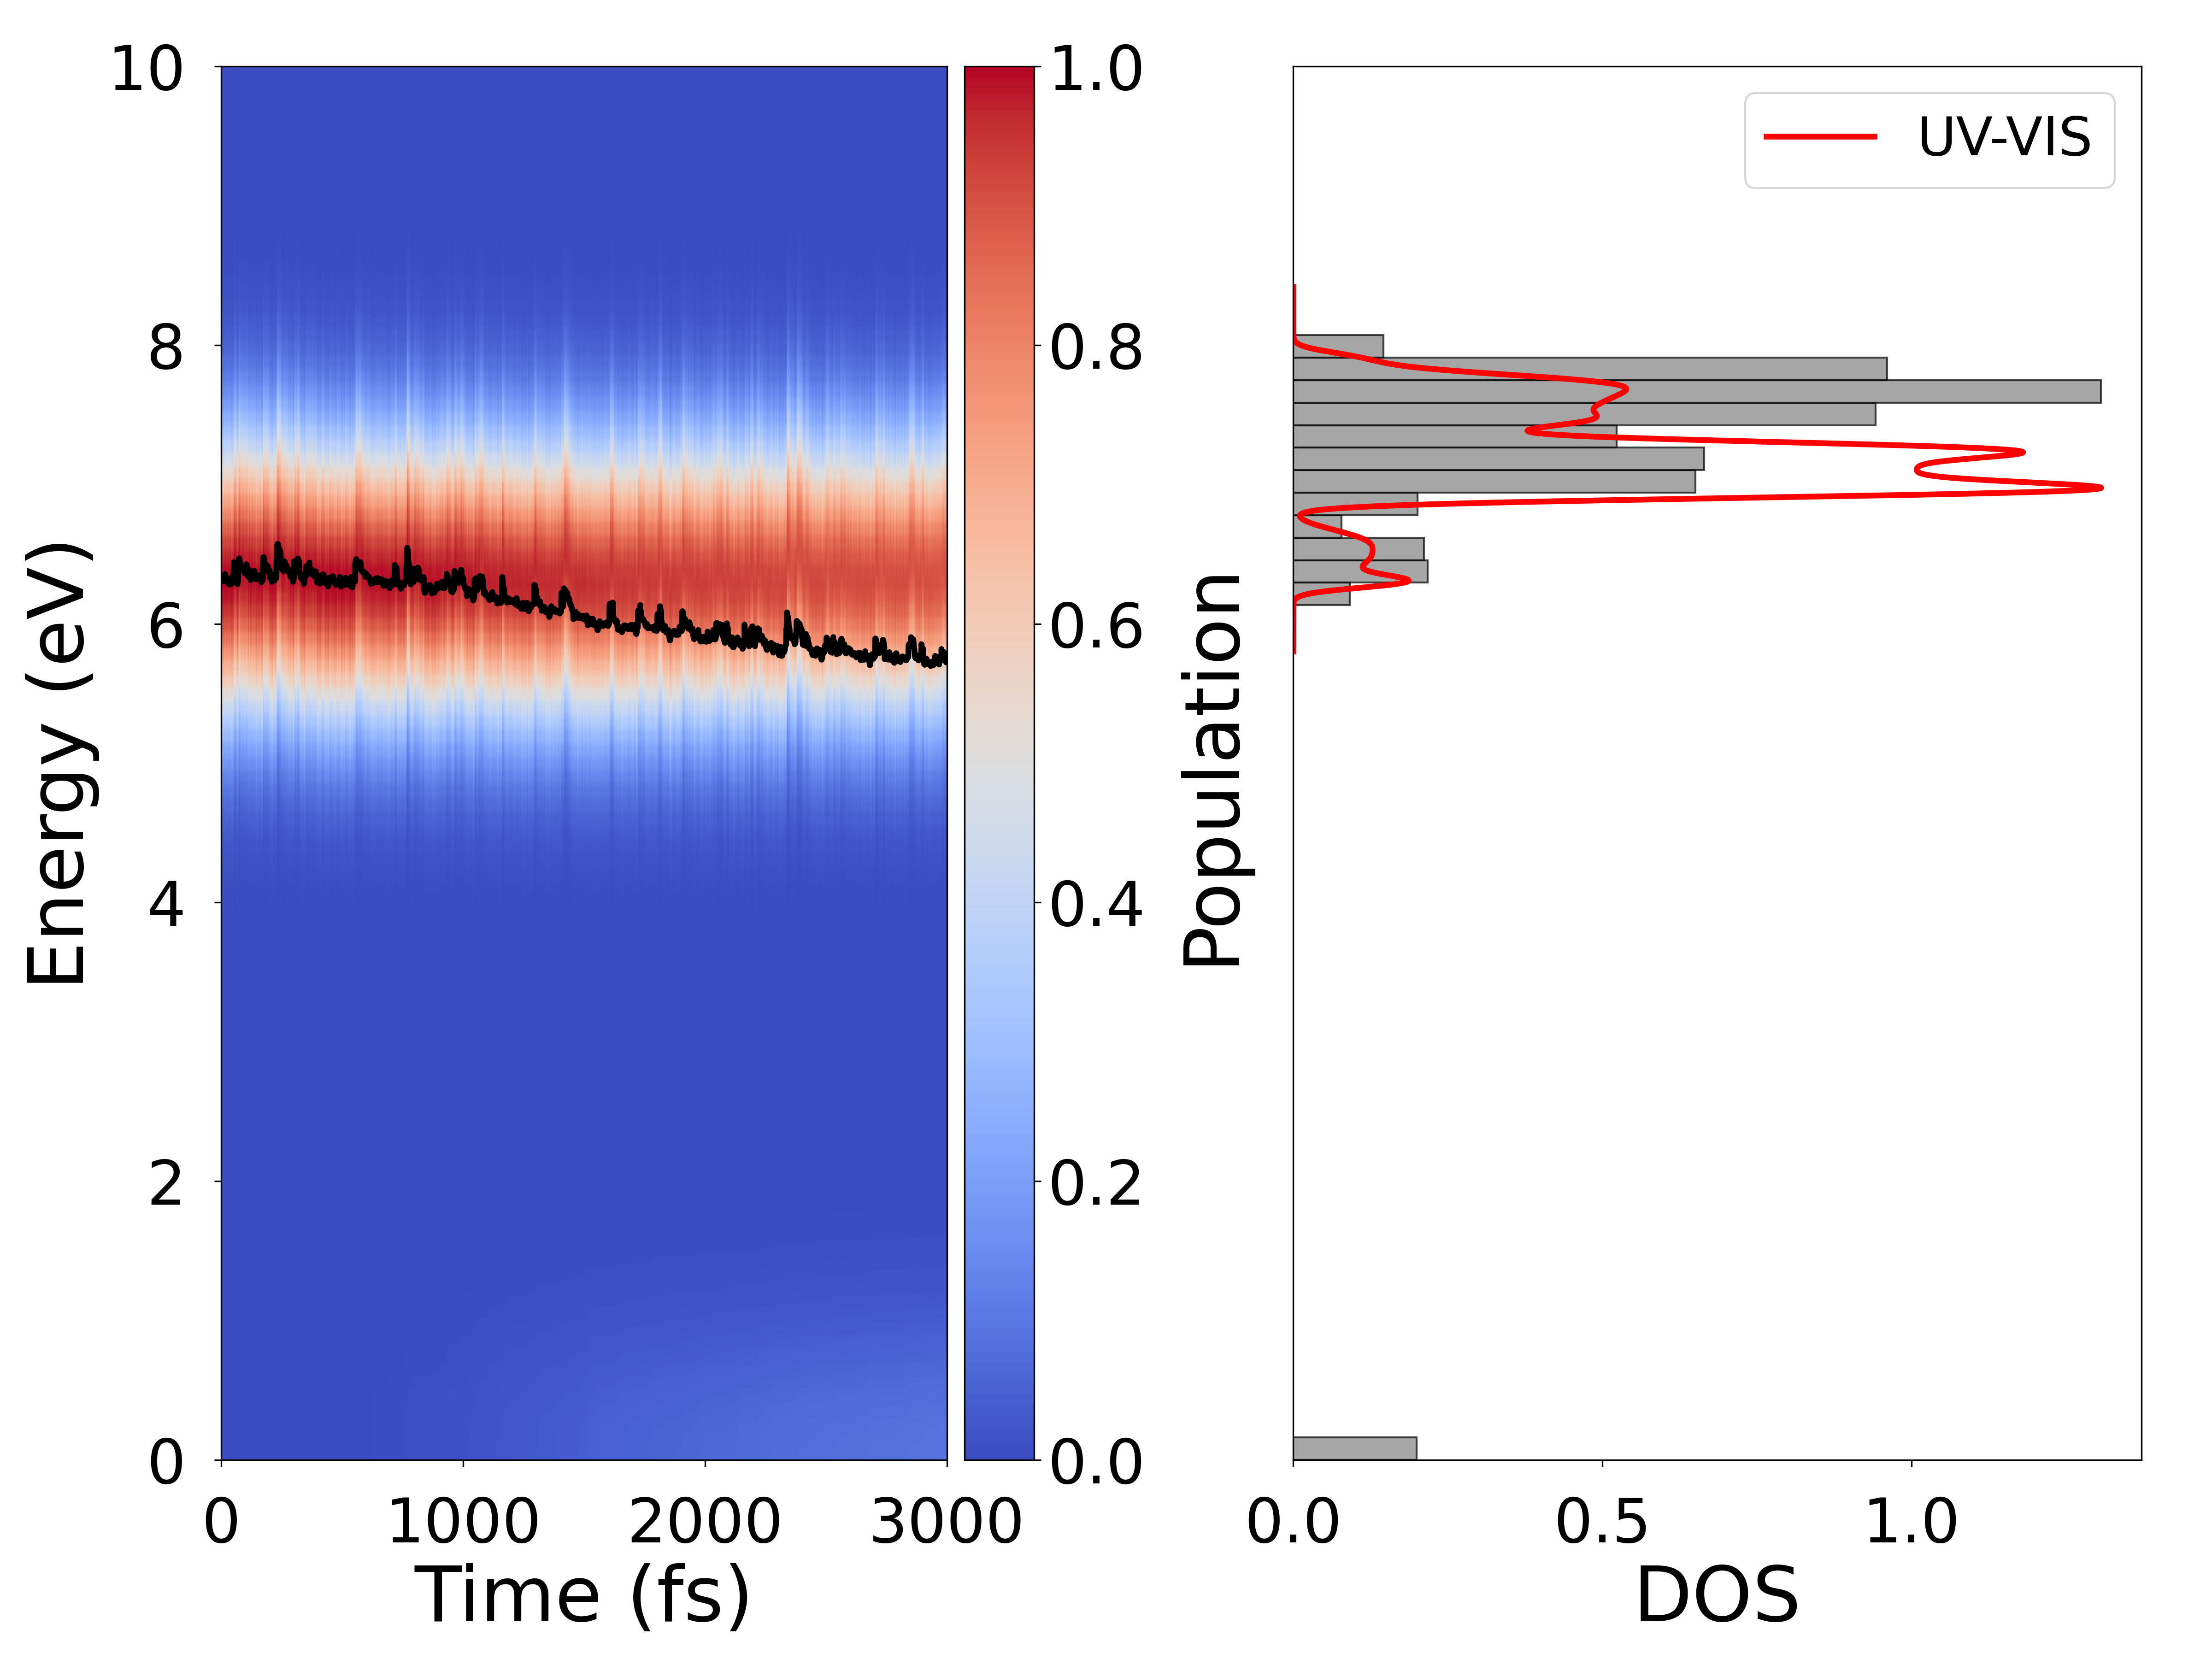